In [57]:
# =========================
# SECTION 2: IMPORTS + CONFIG
# =========================

import pandas as pd
import numpy as np
from datetime import datetime
import yfinance as yf

# Data settings
DATA_PERIOD = "1y"
DATA_INTERVAL = "1d"

# Indicator settings
MOMENTUM_WINDOW = 20
VOLUME_WINDOW = 20
VOLATILITY_WINDOW = 20
SHORT_SMA_WINDOW = 20
LONG_SMA_WINDOW = 50

# Strategy thresholds
MIN_MOMENTUM_20D = 0.05       # +5% over 20 trading days
MIN_VOLUME_RATIO = 1.00       # today's volume >= 20-day average volume
MAX_VOLATILITY_20D = 0.03     # daily return standard deviation below 3%

# Risk/liquidity settings
MIN_AVG_DOLLAR_VOLUME = 10_000_000  # $10 million average daily dollar volume

# Disaster kill switch setting
DISASTER_DRAWDOWN_LIMIT = 0.45       # 45% daily equity drop

print("Config loaded.")

Config loaded.


In [58]:
# %%
# =========================
# SECTION 1: BASE STOCK UNIVERSE
# =========================

"""
Base universe:
These are the stocks the bot is allowed to consider.

Important:
This is NOT the portfolio.
The bot will dynamically filter and rank these stocks each month.
"""

STOCK_UNIVERSE = {
    # Technology
    "AAPL": "Technology",
    "MSFT": "Technology",
    "NVDA": "Technology",
    "AVGO": "Technology",
    "AMD": "Technology",
    "ADBE": "Technology",
    "CRM": "Technology",
    "ORCL": "Technology",
    "CSCO": "Technology",
    "INTC": "Technology",
    "QCOM": "Technology",
    "TXN": "Technology",
    "AMAT": "Technology",
    "NOW": "Technology",

    # Communication Services
    "GOOGL": "Communication Services",
    "META": "Communication Services",
    "NFLX": "Communication Services",
    "DIS": "Communication Services",
    "CMCSA": "Communication Services",
    "TMUS": "Communication Services",

    # Consumer Discretionary
    "AMZN": "Consumer Discretionary",
    "TSLA": "Consumer Discretionary",
    "HD": "Consumer Discretionary",
    "MCD": "Consumer Discretionary",
    "NKE": "Consumer Discretionary",
    "SBUX": "Consumer Discretionary",
    "LOW": "Consumer Discretionary",

    # Consumer Staples
    "WMT": "Consumer Staples",
    "COST": "Consumer Staples",
    "PG": "Consumer Staples",
    "KO": "Consumer Staples",
    "PEP": "Consumer Staples",
    "PM": "Consumer Staples",

    # Financials
    "JPM": "Financials",
    "BAC": "Financials",
    "WFC": "Financials",
    "GS": "Financials",
    "MS": "Financials",
    "V": "Financials",
    "MA": "Financials",
    "AXP": "Financials",
    "BLK": "Financials",

    # Healthcare
    "JNJ": "Healthcare",
    "LLY": "Healthcare",
    "UNH": "Healthcare",
    "ABBV": "Healthcare",
    "MRK": "Healthcare",
    "PFE": "Healthcare",
    "TMO": "Healthcare",
    "ABT": "Healthcare",

    # Energy
    "XOM": "Energy",
    "CVX": "Energy",
    "COP": "Energy",
    "SLB": "Energy",

    # Industrials
    "CAT": "Industrials",
    "BA": "Industrials",
    "HON": "Industrials",
    "GE": "Industrials",
    "UPS": "Industrials",
    "RTX": "Industrials",

    # Materials
    "LIN": "Materials",
    "APD": "Materials",
    "SHW": "Materials",

    # Utilities / Defensive
    "NEE": "Utilities",
    "DUK": "Utilities",
    "SO": "Utilities",

    # Real Estate
    "AMT": "Real Estate",
    "PLD": "Real Estate",
    "EQIX": "Real Estate"
}

TICKERS = list(STOCK_UNIVERSE.keys())

print(f"Number of stocks in base universe: {len(TICKERS)}")
print(TICKERS)

Number of stocks in base universe: 69
['AAPL', 'MSFT', 'NVDA', 'AVGO', 'AMD', 'ADBE', 'CRM', 'ORCL', 'CSCO', 'INTC', 'QCOM', 'TXN', 'AMAT', 'NOW', 'GOOGL', 'META', 'NFLX', 'DIS', 'CMCSA', 'TMUS', 'AMZN', 'TSLA', 'HD', 'MCD', 'NKE', 'SBUX', 'LOW', 'WMT', 'COST', 'PG', 'KO', 'PEP', 'PM', 'JPM', 'BAC', 'WFC', 'GS', 'MS', 'V', 'MA', 'AXP', 'BLK', 'JNJ', 'LLY', 'UNH', 'ABBV', 'MRK', 'PFE', 'TMO', 'ABT', 'XOM', 'CVX', 'COP', 'SLB', 'CAT', 'BA', 'HON', 'GE', 'UPS', 'RTX', 'LIN', 'APD', 'SHW', 'NEE', 'DUK', 'SO', 'AMT', 'PLD', 'EQIX']


In [59]:
# =========================
# SECTION 3: DATA COLLECTION
# =========================

def get_stock_data(ticker, period=DATA_PERIOD, interval=DATA_INTERVAL):
    """
    Downloads OHLCV stock data for a single ticker using yfinance.

    OHLCV:
    Open   = opening price
    High   = highest price during the period
    Low    = lowest price during the period
    Close  = closing price
    Volume = number of shares traded
    """

    data = yf.download(
        ticker,
        period=period,
        interval=interval,
        progress=False,
        auto_adjust=True
    )

    if data.empty:
        raise ValueError(f"No data returned for {ticker}")

    # Flatten columns if yfinance returns multi-index columns
    if isinstance(data.columns, pd.MultiIndex):
        data.columns = data.columns.get_level_values(0)

    data = data.dropna()

    return data


def collect_universe_data(tickers):
    """
    Downloads data for all tickers in the stock universe.
    Returns a dictionary:

    {
        "AAPL": dataframe,
        "MSFT": dataframe,
        ...
    }
    """

    stock_data = {}

    for ticker in tickers:
        try:
            data = get_stock_data(ticker)
            stock_data[ticker] = data
            print(f"Downloaded data for {ticker}: {len(data)} rows")

        except Exception as e:
            print(f"Failed to download {ticker}: {e}")

    return stock_data


stock_data = collect_universe_data(TICKERS)

print(f"\nSuccessfully downloaded data for {len(stock_data)} stocks.")

Downloaded data for AAPL: 251 rows
Downloaded data for MSFT: 251 rows
Downloaded data for NVDA: 251 rows
Downloaded data for AVGO: 251 rows
Downloaded data for AMD: 251 rows
Downloaded data for ADBE: 251 rows
Downloaded data for CRM: 251 rows
Downloaded data for ORCL: 251 rows
Downloaded data for CSCO: 251 rows
Downloaded data for INTC: 251 rows
Downloaded data for QCOM: 251 rows
Downloaded data for TXN: 251 rows
Downloaded data for AMAT: 251 rows
Downloaded data for NOW: 251 rows
Downloaded data for GOOGL: 251 rows
Downloaded data for META: 251 rows
Downloaded data for NFLX: 251 rows
Downloaded data for DIS: 251 rows
Downloaded data for CMCSA: 251 rows
Downloaded data for TMUS: 251 rows
Downloaded data for AMZN: 251 rows
Downloaded data for TSLA: 251 rows
Downloaded data for HD: 251 rows
Downloaded data for MCD: 251 rows
Downloaded data for NKE: 251 rows
Downloaded data for SBUX: 251 rows
Downloaded data for LOW: 251 rows
Downloaded data for WMT: 251 rows
Downloaded data for COST: 251

In [60]:
# =========================
# SECTION 4: INDICATOR CALCULATION
# =========================

def calculate_indicators(data):
    """
    Adds technical indicators to the dataframe.

    Indicators:
    - Daily returns
    - 20-day momentum
    - 20-day average volume
    - Volume ratio
    - 20-day volatility using standard deviation of returns
    - 20-day and 50-day moving averages
    - Average dollar volume
    """

    data = data.copy()

    # Daily returns
    data["Return"] = data["Close"].pct_change()

    # Momentum: percentage change over previous 20 trading days
    data["Momentum_20D"] = data["Close"].pct_change(MOMENTUM_WINDOW)

    # Volume ratio: today's volume divided by average volume
    data["Avg_Volume_20D"] = data["Volume"].rolling(VOLUME_WINDOW).mean()
    data["Volume_Ratio"] = data["Volume"] / data["Avg_Volume_20D"]

    # Volatility: rolling standard deviation of daily returns
    data["Volatility_20D"] = data["Return"].rolling(VOLATILITY_WINDOW).std()

    # Trend: moving averages
    data["SMA_20"] = data["Close"].rolling(SHORT_SMA_WINDOW).mean()
    data["SMA_50"] = data["Close"].rolling(LONG_SMA_WINDOW).mean()

    # Dollar volume: price × volume
    data["Dollar_Volume"] = data["Close"] * data["Volume"]
    data["Avg_Dollar_Volume_20D"] = data["Dollar_Volume"].rolling(VOLUME_WINDOW).mean()

    return data


indicator_data = {}

for ticker, data in stock_data.items():
    indicator_data[ticker] = calculate_indicators(data)

print("Indicators calculated.")

Indicators calculated.


In [61]:
# =========================
# SECTION 5: STRATEGY LOGIC
# =========================

def evaluate_strategy(ticker, data):
    """
    Evaluates the current strategy conditions for a stock.

    Strategy checks:
    - Momentum is strong
    - Volume is healthy
    - Volatility is acceptable
    - Trend is upward
    - Liquidity is acceptable
    """

    latest = data.dropna().iloc[-1]

    momentum_20d = latest["Momentum_20D"]
    volume_ratio = latest["Volume_Ratio"]
    volatility_20d = latest["Volatility_20D"]
    sma_20 = latest["SMA_20"]
    sma_50 = latest["SMA_50"]
    avg_dollar_volume_20d = latest["Avg_Dollar_Volume_20D"]
    close_price = latest["Close"]

    # Strategy checks
    momentum_ok = momentum_20d > MIN_MOMENTUM_20D
    volume_ok = volume_ratio > MIN_VOLUME_RATIO
    volatility_ok = volatility_20d < MAX_VOLATILITY_20D
    trend_ok = sma_20 > sma_50
    liquidity_ok = avg_dollar_volume_20d > MIN_AVG_DOLLAR_VOLUME

    return {
        "Ticker": ticker,
        "Sector": STOCK_UNIVERSE.get(ticker, "Unknown"),
        "Close": close_price,
        "Momentum_20D": momentum_20d,
        "Volume_Ratio": volume_ratio,
        "Volatility_20D": volatility_20d,
        "SMA_20": sma_20,
        "SMA_50": sma_50,
        "Avg_Dollar_Volume_20D": avg_dollar_volume_20d,

        "momentum_ok": momentum_ok,
        "volume_ok": volume_ok,
        "volatility_ok": volatility_ok,
        "trend_ok": trend_ok,
        "liquidity_ok": liquidity_ok
    }


strategy_results = []

for ticker, data in indicator_data.items():
    try:
        result = evaluate_strategy(ticker, data)
        strategy_results.append(result)

    except Exception as e:
        print(f"Could not evaluate strategy for {ticker}: {e}")

strategy_df = pd.DataFrame(strategy_results)

strategy_df.head()

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,SMA_20,SMA_50,Avg_Dollar_Volume_20D,momentum_ok,volume_ok,volatility_ok,trend_ok,liquidity_ok
0,AAPL,Technology,298.869995,0.122792,1.070946,0.015602,278.090619,264.449287,1.367693e+10,True,True,True,True,True
1,MSFT,Technology,405.209991,-0.014615,0.841736,0.017899,417.990500,398.755399,1.467670e+10,False,False,True,True,True
2,NVDA,Technology,225.830002,0.135566,0.994465,0.024192,207.249500,191.176613,3.121933e+10,True,False,True,True,True
3,AVGO,Technology,416.790009,0.050590,0.877875,0.023537,415.536501,364.930795,8.025521e+09,True,False,True,True,True
4,AMD,Technology,445.500000,0.725941,0.620201,0.062854,355.854501,269.767000,1.750532e+10,True,False,False,True,True


In [62]:
# =========================
# SECTION 6: SIGNAL GENERATION + RISK ASSESSMENT
# =========================

def calculate_technical_score(row):
    """
    Calculates a simple technical score out of 9.

    Current scoring:
    - Momentum: up to 3 points
    - Trend: up to 2 points
    - Volume: up to 2 points
    - Volatility: up to 1 point
    - Liquidity: up to 1 point
    """

    score = 0

    # Momentum score
    if row["Momentum_20D"] > 0.10:
        score += 3
    elif row["Momentum_20D"] > 0.05:
        score += 2
    elif row["Momentum_20D"] > 0:
        score += 1

    # Trend score
    if row["trend_ok"]:
        score += 2

    # Volume score
    if row["Volume_Ratio"] > 1.5:
        score += 2
    elif row["Volume_Ratio"] > 1.0:
        score += 1

    # Volatility score
    if row["volatility_ok"]:
        score += 1

    # Liquidity score
    if row["liquidity_ok"]:
        score += 1

    return score


def generate_signal(row):
    """
    Converts strategy results into a trading signal.

    BUY:
    Strong technical setup and risk filters pass.

    WATCHLIST:
    Decent setup but not strong enough.

    AVOID:
    Weak setup or failed important filters.

    SELL:
    Trend is broken.
    """

    # If trend is broken, this is not a buy candidate
    if not row["trend_ok"]:
        return "SELL / AVOID"

    # Hard avoid if liquidity is poor
    if not row["liquidity_ok"]:
        return "AVOID - LOW LIQUIDITY"

    # Hard avoid if volatility is too high
    if not row["volatility_ok"]:
        return "AVOID - HIGH VOLATILITY"

    # Strong setup
    if (
        row["momentum_ok"]
        and row["volume_ok"]
        and row["volatility_ok"]
        and row["trend_ok"]
        and row["liquidity_ok"]
    ):
        return "BUY"

    # Otherwise, maybe worth watching
    return "WATCHLIST"


def assess_stock_risk(row):
    """
    Gives a simple risk label for the stock.

    This is stock-level risk, not portfolio-level risk.
    """

    risks = []

    if not row["liquidity_ok"]:
        risks.append("Low liquidity")

    if not row["volatility_ok"]:
        risks.append("High volatility")

    if row["Volume_Ratio"] < 0.75:
        risks.append("Weak volume")

    if row["Momentum_20D"] < 0:
        risks.append("Negative momentum")

    if not row["trend_ok"]:
        risks.append("Downtrend")

    if len(risks) == 0:
        return "OK"

    return ", ".join(risks)


def check_disaster_kill_switch(starting_day_equity, current_equity):
    """
    Disaster-level portfolio risk check.

    If portfolio equity drops 45% or more from start-of-day equity,
    stop trading and notify the user.

    portfolio equity = cash + market value of positions
    """

    if starting_day_equity <= 0:
        raise ValueError("starting_day_equity must be greater than 0")

    drawdown = (starting_day_equity - current_equity) / starting_day_equity

    if drawdown >= DISASTER_DRAWDOWN_LIMIT:
        return {
            "status": "DISASTER_STOP",
            "stop_trading": True,
            "notify_user": True,
            "drawdown": drawdown
        }

    return {
        "status": "OK",
        "stop_trading": False,
        "notify_user": False,
        "drawdown": drawdown
    }


# Apply scoring, signal generation, and risk assessment
strategy_df["Technical_Score"] = strategy_df.apply(calculate_technical_score, axis=1)
strategy_df["Signal"] = strategy_df.apply(generate_signal, axis=1)
strategy_df["Risk_Notes"] = strategy_df.apply(assess_stock_risk, axis=1)

# Sort best candidates first
ranked_df = strategy_df.sort_values(
    by=["Technical_Score", "Momentum_20D"],
    ascending=[False, False]
).reset_index(drop=True)

# Make the table easier to read
display_cols = [
    "Ticker",
    "Sector",
    "Close",
    "Momentum_20D",
    "Volume_Ratio",
    "Volatility_20D",
    "Technical_Score",
    "Signal",
    "Risk_Notes"
]

ranked_output = ranked_df[display_cols].copy()

# Format percentages for readability
ranked_output["Momentum_20D"] = ranked_output["Momentum_20D"].apply(lambda x: f"{x:.2%}")
ranked_output["Volatility_20D"] = ranked_output["Volatility_20D"].apply(lambda x: f"{x:.2%}")
ranked_output["Volume_Ratio"] = ranked_output["Volume_Ratio"].apply(lambda x: f"{x:.2f}")
ranked_output["Close"] = ranked_output["Close"].apply(lambda x: f"${x:.2f}")

ranked_output

,Ticker,Sector,Close,Momentum_20D,Volume_Ratio,Volatility_20D,Technical_Score,Signal,Risk_Notes
0,CSCO,Technology,$101.87,23.69%,2.12,1.81%,9,BUY,OK
1,GOOGL,Communication Services,$402.62,19.43%,1.00,2.64%,8,BUY,OK
2,TSLA,Consumer Discretionary,$445.27,13.60%,1.08,2.25%,8,BUY,OK
3,AAPL,Technology,$298.87,12.28%,1.07,1.56%,8,BUY,OK
4,UNH,Healthcare,$401.16,27.74%,0.99,1.89%,7,WATCHLIST,OK
...,...,...,...,...,...,...,...,...,...
64,ABT,Healthcare,$83.83,-17.46%,0.81,2.01%,2,SELL / AVOID,"Negative momentum, Downtrend"
65,NFLX,Communication Services,$87.56,-18.71%,0.70,2.53%,2,SELL / AVOID,"Weak volume, Negative momentum, Downtrend"
66,CRM,Technology,$165.84,-6.62%,0.96,3.01%,1,SELL / AVOID,"High volatility, Negative momentum, Downtrend"
67,NOW,Technology,$87.05,-7.58%,0.81,4.86%,1,SELL / AVOID,"High volatility, Negative momentum, Downtrend"


In [63]:
# =========================
# OPTIONAL: TEST DISASTER KILL SWITCH
# =========================

starting_day_equity = 10_000
current_equity = 5_400

kill_switch_result = check_disaster_kill_switch(
    starting_day_equity=starting_day_equity,
    current_equity=current_equity
)

kill_switch_result

{'status': 'DISASTER_STOP',
 'stop_trading': True,
 'notify_user': True,
 'drawdown': 0.46}

In [64]:
# =========================
# SECTION 7A: BACKTEST DATA
# =========================

BACKTEST_PERIOD = "10y"
BENCHMARK_TICKER = "SPY"

def collect_backtest_data(tickers, benchmark_ticker=BENCHMARK_TICKER):
    """
    Downloads longer historical data for the 20-stock universe
    plus a market benchmark like SPY.
    """

    all_tickers = tickers + [benchmark_ticker]
    data_dict = {}

    for ticker in all_tickers:
        try:
            data = get_stock_data(
                ticker,
                period=BACKTEST_PERIOD,
                interval="1d"
            )

            data_dict[ticker] = data
            print(f"Downloaded {ticker}: {len(data)} rows")

        except Exception as e:
            print(f"Failed to download {ticker}: {e}")

    return data_dict


backtest_data = collect_backtest_data(TICKERS)

Downloaded AAPL: 2513 rows
Downloaded MSFT: 2513 rows
Downloaded NVDA: 2513 rows
Downloaded AVGO: 2513 rows
Downloaded AMD: 2513 rows
Downloaded ADBE: 2513 rows
Downloaded CRM: 2513 rows
Downloaded ORCL: 2513 rows
Downloaded CSCO: 2513 rows
Downloaded INTC: 2513 rows
Downloaded QCOM: 2513 rows
Downloaded TXN: 2513 rows
Downloaded AMAT: 2513 rows
Downloaded NOW: 2513 rows
Downloaded GOOGL: 2513 rows
Downloaded META: 2513 rows
Downloaded NFLX: 2513 rows
Downloaded DIS: 2513 rows
Downloaded CMCSA: 2513 rows
Downloaded TMUS: 2513 rows
Downloaded AMZN: 2513 rows
Downloaded TSLA: 2513 rows
Downloaded HD: 2513 rows
Downloaded MCD: 2513 rows
Downloaded NKE: 2513 rows
Downloaded SBUX: 2513 rows
Downloaded LOW: 2513 rows
Downloaded WMT: 2513 rows
Downloaded COST: 2513 rows
Downloaded PG: 2513 rows
Downloaded KO: 2513 rows
Downloaded PEP: 2513 rows
Downloaded PM: 2513 rows
Downloaded JPM: 2513 rows
Downloaded BAC: 2513 rows
Downloaded WFC: 2513 rows
Downloaded GS: 2513 rows
Downloaded MS: 2513 ro

In [65]:
# %%
# =========================
# SECTION 7B-0: DYNAMIC UNIVERSE SELECTION
# =========================

def select_dynamic_universe(
    data_dict,
    tickers,
    yesterday,
    min_avg_dollar_volume=MIN_AVG_DOLLAR_VOLUME,
    max_volatility=MAX_VOLATILITY_20D,
    require_uptrend=True
):
    """
    Selects the eligible stock universe for a specific rebalance date.

    This is different from portfolio selection.

    Universe selection answers:
    "Which stocks are allowed to be considered?"

    Portfolio selection answers:
    "Which stocks should we actually hold?"
    """

    eligible_tickers = []

    for ticker in tickers:
        historical_data = data_dict[ticker].loc[:yesterday].copy()

        # Need enough history for indicators
        if len(historical_data) < 60:
            continue

        indicator_data = calculate_indicators(historical_data)
        clean_data = indicator_data.dropna()

        if clean_data.empty:
            continue

        latest = clean_data.iloc[-1]

        avg_dollar_volume = latest["Avg_Dollar_Volume_20D"]
        volatility = latest["Volatility_20D"]
        sma_20 = latest["SMA_20"]
        sma_50 = latest["SMA_50"]

        liquidity_ok = avg_dollar_volume > min_avg_dollar_volume
        volatility_ok = volatility < max_volatility

        if require_uptrend:
            trend_ok = sma_20 > sma_50
        else:
            trend_ok = True

        if liquidity_ok and volatility_ok and trend_ok:
            eligible_tickers.append(ticker)

    return eligible_tickers

In [66]:
# %%
# =========================
# SECTION 7B: MONTHLY DYNAMIC PORTFOLIO BACKTESTER
# =========================

def get_common_dates(data_dict, tickers):
    """
    Finds dates that are common across all selected stocks.
    This keeps the backtest aligned across all tickers.
    """

    date_sets = []

    for ticker in tickers:
        dates = set(data_dict[ticker].index)
        date_sets.append(dates)

    common_dates = sorted(set.intersection(*date_sets))

    return common_dates


def calculate_portfolio_value(cash, positions, data_dict, date):
    """
    Calculates total portfolio value.

    Portfolio value = cash + current value of all stock positions.
    """

    positions_value = 0

    for ticker, position in positions.items():
        shares = position["shares"]
        close_price = data_dict[ticker].loc[date, "Close"]
        positions_value += shares * close_price

    return cash + positions_value


def get_monthly_rebalance_dates(common_dates):
    """
    Converts daily trading dates into month-end rebalance dates.

    The rebalance date is the last available trading day of each month.
    """

    dates_df = pd.DataFrame({"Date": pd.to_datetime(common_dates)})
    dates_df["YearMonth"] = dates_df["Date"].dt.to_period("M")

    rebalance_dates = dates_df.groupby("YearMonth")["Date"].max()

    return set(rebalance_dates)

def rank_stocks_for_date(data_dict, tickers, yesterday):
    """
    Ranks stocks using only data available up to yesterday.

    This version first applies dynamic universe selection.
    Then it ranks only the eligible stocks.
    """

    # Select the dynamic eligible universe first
    eligible_tickers = select_dynamic_universe(
        data_dict=data_dict,
        tickers=tickers,
        yesterday=yesterday,
        min_avg_dollar_volume=MIN_AVG_DOLLAR_VOLUME,
        max_volatility=MAX_VOLATILITY_20D,
        require_uptrend=True
    )

    daily_candidates = []

    for ticker in eligible_tickers:
        historical_data = data_dict[ticker].loc[:yesterday].copy()

        if len(historical_data) < 60:
            continue

        indicator_data = calculate_indicators(historical_data)

        try:
            strategy_result = evaluate_strategy(ticker, indicator_data)
            row = pd.Series(strategy_result)

            technical_score = calculate_technical_score(row)
            signal = generate_signal(row)

            daily_candidates.append({
                "Ticker": ticker,
                "Signal": signal,
                "Technical_Score": technical_score,
                "Momentum_20D": strategy_result["Momentum_20D"],
                "Volatility_20D": strategy_result["Volatility_20D"],
                "Sector": strategy_result["Sector"]
            })

        except Exception:
            continue

    daily_candidates_df = pd.DataFrame(daily_candidates)

    if daily_candidates_df.empty:
        return daily_candidates_df

    daily_candidates_df = daily_candidates_df.sort_values(
        by=["Technical_Score", "Momentum_20D"],
        ascending=[False, False]
    ).reset_index(drop=True)

    daily_candidates_df["Rank"] = daily_candidates_df.index + 1

    return daily_candidates_df


def backtest_monthly_dynamic_portfolio(
    data_dict,
    tickers,
    initial_cash=10_000,
    max_positions=5,
    exit_rank_buffer=8,
    transaction_cost_rate=0.001
):
    """
    Monthly dynamic portfolio backtest.

    Logic:
    - Uses data up to yesterday to rank stocks.
    - Only rebalances at the end of each month.
    - Keeps current holdings if they are still ranked reasonably well.
    - Replaces weak holdings with better-ranked BUY candidates.
    - Uses fractional shares.
    """

    cash = initial_cash
    positions = {}

    portfolio_history = []
    trade_log = []

    common_dates = get_common_dates(data_dict, tickers)
    rebalance_dates = get_monthly_rebalance_dates(common_dates)

    start_index = 60

    for i in range(start_index, len(common_dates)):
        today = common_dates[i]
        yesterday = common_dates[i - 1]

        today_timestamp = pd.to_datetime(today)

        # =========================
        # 1. Monthly rebalance only
        # =========================

        if today_timestamp in rebalance_dates:

            ranked_df = rank_stocks_for_date(
                data_dict=data_dict,
                tickers=tickers,
                yesterday=yesterday
            )

            if not ranked_df.empty:

                # Current portfolio value before rebalancing
                current_equity = calculate_portfolio_value(
                    cash,
                    positions,
                    data_dict,
                    today
                )

                # -------------------------
                # A. Decide which current holdings to keep
                # -------------------------

                holdings_to_keep = []

                for ticker in positions.keys():
                    ticker_row = ranked_df[ranked_df["Ticker"] == ticker]

                    if ticker_row.empty:
                        continue

                    signal = ticker_row.iloc[0]["Signal"]
                    rank = ticker_row.iloc[0]["Rank"]

                    # Keep if still decent and not an avoid/sell signal
                    if (
                        rank <= exit_rank_buffer
                        and "SELL" not in signal
                        and "AVOID" not in signal
                    ):
                        holdings_to_keep.append(ticker)

                # -------------------------
                # B. Sell holdings not kept
                # -------------------------

                for ticker in list(positions.keys()):
                    if ticker not in holdings_to_keep:
                        open_price = data_dict[ticker].loc[today, "Open"]
                        shares = positions[ticker]["shares"]

                        trade_value = shares * open_price
                        transaction_cost = trade_value * transaction_cost_rate

                        cash += trade_value - transaction_cost

                        trade_log.append({
                            "Date": today,
                            "Ticker": ticker,
                            "Action": "SELL",
                            "Price": open_price,
                            "Shares": shares,
                            "Trade_Value": trade_value,
                            "Transaction_Cost": transaction_cost,
                            "Reason": "Monthly rebalance replacement"
                        })

                        del positions[ticker]

                # -------------------------
                # C. Pick new target holdings
                # -------------------------

                buy_candidates = ranked_df[
                    ranked_df["Signal"] == "BUY"
                ].copy()

                target_holdings = list(positions.keys())

                for _, candidate in buy_candidates.iterrows():
                    ticker = candidate["Ticker"]

                    if len(target_holdings) >= max_positions:
                        break

                    if ticker not in target_holdings:
                        target_holdings.append(ticker)

                # -------------------------
                # D. Rebalance equally across target holdings
                # -------------------------

                if len(target_holdings) > 0:

                    current_equity = calculate_portfolio_value(
                        cash,
                        positions,
                        data_dict,
                        today
                    )

                    target_position_value = current_equity / len(target_holdings)

                    new_positions = {}

                    for ticker in target_holdings:
                        open_price = data_dict[ticker].loc[today, "Open"]

                        # Current value if already held
                        if ticker in positions:
                            old_shares = positions[ticker]["shares"]
                            old_value = old_shares * open_price
                        else:
                            old_shares = 0
                            old_value = 0

                        value_difference = target_position_value - old_value

                        # Buy more
                        if value_difference > 0:
                            amount_to_buy = min(cash, value_difference)

                            if amount_to_buy > 0:
                                transaction_cost = amount_to_buy * transaction_cost_rate
                                investable_amount = amount_to_buy - transaction_cost
                                shares_bought = investable_amount / open_price

                                cash -= amount_to_buy

                                new_shares = old_shares + shares_bought

                                trade_log.append({
                                    "Date": today,
                                    "Ticker": ticker,
                                    "Action": "BUY",
                                    "Price": open_price,
                                    "Shares": shares_bought,
                                    "Trade_Value": amount_to_buy,
                                    "Transaction_Cost": transaction_cost,
                                    "Reason": "Monthly rebalance buy/top-up"
                                })

                            else:
                                new_shares = old_shares

                        # Sell some
                        elif value_difference < 0:
                            amount_to_sell = abs(value_difference)
                            shares_to_sell = amount_to_sell / open_price

                            shares_to_sell = min(shares_to_sell, old_shares)

                            trade_value = shares_to_sell * open_price
                            transaction_cost = trade_value * transaction_cost_rate

                            cash += trade_value - transaction_cost

                            new_shares = old_shares - shares_to_sell

                            trade_log.append({
                                "Date": today,
                                "Ticker": ticker,
                                "Action": "SELL",
                                "Price": open_price,
                                "Shares": shares_to_sell,
                                "Trade_Value": trade_value,
                                "Transaction_Cost": transaction_cost,
                                "Reason": "Monthly rebalance trim"
                            })

                        else:
                            new_shares = old_shares

                        if new_shares > 0:
                            new_positions[ticker] = {
                                "shares": new_shares,
                                "entry_price": open_price,
                                "entry_date": today
                            }

                    positions = new_positions

        # =========================
        # 2. Record end-of-day portfolio value
        # =========================

        portfolio_value = calculate_portfolio_value(
            cash,
            positions,
            data_dict,
            today
        )

        portfolio_history.append({
            "Date": today,
            "Portfolio_Value": portfolio_value,
            "Cash": cash,
            "Num_Positions": len(positions),
            "Positions": list(positions.keys())
        })

    portfolio_df = pd.DataFrame(portfolio_history)
    trade_log_df = pd.DataFrame(trade_log)

    return portfolio_df, trade_log_df

In [67]:
portfolio_df, trade_log_df = backtest_monthly_dynamic_portfolio(
    data_dict=backtest_data,
    tickers=TICKERS,
    initial_cash=10_000,
    max_positions=5,
    exit_rank_buffer=8,
    transaction_cost_rate=0.001
)

print("Monthly dynamic backtest complete.")
print(f"Portfolio history rows: {len(portfolio_df)}")
print(f"Number of trades: {len(trade_log_df)}")

portfolio_df.head(), trade_log_df.head()

Monthly dynamic backtest complete.
Portfolio history rows: 2453
Number of trades: 754


(        Date  Portfolio_Value     Cash  Num_Positions Positions
 0 2016-08-10          10000.0  10000.0              0        []
 1 2016-08-11          10000.0  10000.0              0        []
 2 2016-08-12          10000.0  10000.0              0        []
 3 2016-08-15          10000.0  10000.0              0        []
 4 2016-08-16          10000.0  10000.0              0        [],
         Date Ticker Action       Price      Shares  Trade_Value  \
 0 2016-08-31    BAC    BUY   13.100617  152.511902       2000.0   
 1 2016-08-31     MS    BUY   24.384399   81.937636       2000.0   
 2 2016-08-31    WFC    BUY   38.719336   51.602125       2000.0   
 3 2016-08-31     GS    BUY  138.912658   14.383138       2000.0   
 4 2016-08-31   AVGO    BUY   13.597634  146.937332       2000.0   
 
    Transaction_Cost                        Reason  
 0               2.0  Monthly rebalance buy/top-up  
 1               2.0  Monthly rebalance buy/top-up  
 2               2.0  Monthly rebalance 

In [68]:
# =========================
# SECTION 7C: MULTI-BENCHMARK COMPARISON
# =========================

BENCHMARK_TICKERS = {
    "SPY": "S&P 500",
    "QQQ": "Nasdaq 100",
    "VTI": "Total US Market",
    "DIA": "Dow Jones",
    "IWM": "Russell 2000",
    "XLK": "Technology Sector",
    "XLF": "Financials Sector",
    "XLV": "Healthcare Sector"
}


def collect_benchmark_data(benchmark_tickers, period=BACKTEST_PERIOD):
    benchmark_data = {}

    for ticker in benchmark_tickers:
        try:
            data = get_stock_data(
                ticker,
                period=period,
                interval="1d"
            )

            benchmark_data[ticker] = data
            print(f"Downloaded benchmark {ticker}: {len(data)} rows")

        except Exception as e:
            print(f"Failed to download benchmark {ticker}: {e}")

    return benchmark_data


benchmark_data_dict = collect_benchmark_data(list(BENCHMARK_TICKERS.keys()))


def create_single_benchmark_curve(
    benchmark_data,
    portfolio_df,
    initial_cash=10_000
):
    benchmark = benchmark_data.copy()

    portfolio_dates = pd.to_datetime(portfolio_df["Date"])

    start_date = portfolio_dates.min()
    end_date = portfolio_dates.max()

    benchmark = benchmark.loc[start_date:end_date].copy()
    benchmark = benchmark.reset_index()

    if "index" in benchmark.columns:
        benchmark = benchmark.rename(columns={"index": "Date"})

    benchmark["Date"] = pd.to_datetime(benchmark["Date"])

    benchmark = benchmark[
        benchmark["Date"].isin(portfolio_dates)
    ].copy()

    if benchmark.empty:
        raise ValueError("Benchmark data is empty after alignment.")

    start_price = benchmark["Close"].iloc[0]

    benchmark["Benchmark_Value"] = (
        benchmark["Close"] / start_price
    ) * initial_cash

    return benchmark[["Date", "Benchmark_Value"]]


benchmark_curves = {}

for ticker, data in benchmark_data_dict.items():
    try:
        curve = create_single_benchmark_curve(
            benchmark_data=data,
            portfolio_df=portfolio_df,
            initial_cash=10_000
        )

        benchmark_curves[ticker] = curve

    except Exception as e:
        print(f"Could not create benchmark curve for {ticker}: {e}")

Downloaded benchmark SPY: 2513 rows
Downloaded benchmark QQQ: 2513 rows
Downloaded benchmark VTI: 2513 rows
Downloaded benchmark DIA: 2513 rows
Downloaded benchmark IWM: 2513 rows
Downloaded benchmark XLK: 2513 rows
Downloaded benchmark XLF: 2513 rows
Downloaded benchmark XLV: 2513 rows


In [69]:
# =========================
# SECTION 7D: MULTI-BENCHMARK METRICS
# =========================

def calculate_max_drawdown(values):
    values = pd.Series(values)
    running_max = values.cummax()
    drawdown = (values - running_max) / running_max
    return drawdown.min()


def calculate_total_return(values):
    return (values.iloc[-1] / values.iloc[0]) - 1


def compare_strategy_to_benchmarks(portfolio_df, benchmark_curves):
    results = []

    strategy_values = portfolio_df["Portfolio_Value"]

    strategy_return = calculate_total_return(strategy_values)
    strategy_drawdown = calculate_max_drawdown(strategy_values)

    results.append({
        "Name": "Strategy",
        "Ticker": "BOT",
        "Total_Return": strategy_return,
        "Max_Drawdown": strategy_drawdown,
        "Final_Value": strategy_values.iloc[-1]
    })

    for ticker, curve in benchmark_curves.items():
        benchmark_values = curve["Benchmark_Value"]

        results.append({
            "Name": BENCHMARK_TICKERS.get(ticker, ticker),
            "Ticker": ticker,
            "Total_Return": calculate_total_return(benchmark_values),
            "Max_Drawdown": calculate_max_drawdown(benchmark_values),
            "Final_Value": benchmark_values.iloc[-1]
        })

    results_df = pd.DataFrame(results)

    results_df = results_df.sort_values(
        by="Total_Return",
        ascending=False
    ).reset_index(drop=True)

    return results_df


fund_comparison_df = compare_strategy_to_benchmarks(
    portfolio_df=portfolio_df,
    benchmark_curves=benchmark_curves
)

display_fund_comparison = fund_comparison_df.copy()

display_fund_comparison["Total_Return"] = display_fund_comparison["Total_Return"].apply(lambda x: f"{x:.2%}")
display_fund_comparison["Max_Drawdown"] = display_fund_comparison["Max_Drawdown"].apply(lambda x: f"{x:.2%}")
display_fund_comparison["Final_Value"] = display_fund_comparison["Final_Value"].apply(lambda x: f"${x:,.2f}")

display_fund_comparison

,Name,Ticker,Total_Return,Max_Drawdown,Final_Value
0,Strategy,BOT,787.03%,-30.04%,"$88,702.74"
1,Technology Sector,XLK,735.18%,-33.56%,"$83,518.10"
2,Nasdaq 100,QQQ,556.05%,-35.12%,"$65,604.63"
3,S&P 500,SPY,299.38%,-33.72%,"$39,937.87"
4,Total US Market,VTI,283.02%,-35.00%,"$38,301.60"
5,Dow Jones,DIA,225.15%,-36.70%,"$32,514.60"
6,Financials Sector,XLF,215.19%,-42.86%,"$31,519.27"
7,Russell 2000,IWM,163.10%,-41.13%,"$26,310.19"
8,Healthcare Sector,XLV,131.66%,-28.40%,"$23,166.23"


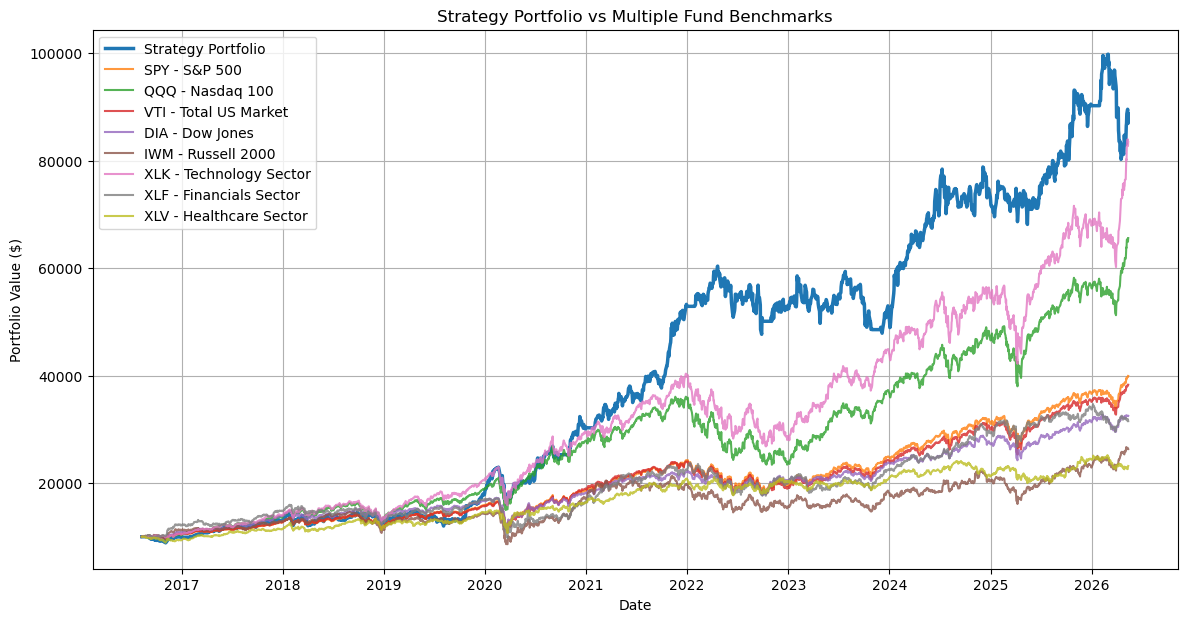

In [70]:
# =========================
# SECTION 7E: PLOT STRATEGY VS MULTIPLE FUNDS
# =========================

import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

plt.plot(
    portfolio_df["Date"],
    portfolio_df["Portfolio_Value"],
    label="Strategy Portfolio",
    linewidth=2.5
)

for ticker, curve in benchmark_curves.items():
    plt.plot(
        curve["Date"],
        curve["Benchmark_Value"],
        label=f"{ticker} - {BENCHMARK_TICKERS.get(ticker, ticker)}",
        alpha=0.8
    )

plt.xlabel("Date")
plt.ylabel("Portfolio Value ($)")
plt.title("Strategy Portfolio vs Multiple Fund Benchmarks")
plt.legend()
plt.grid(True)
plt.show()